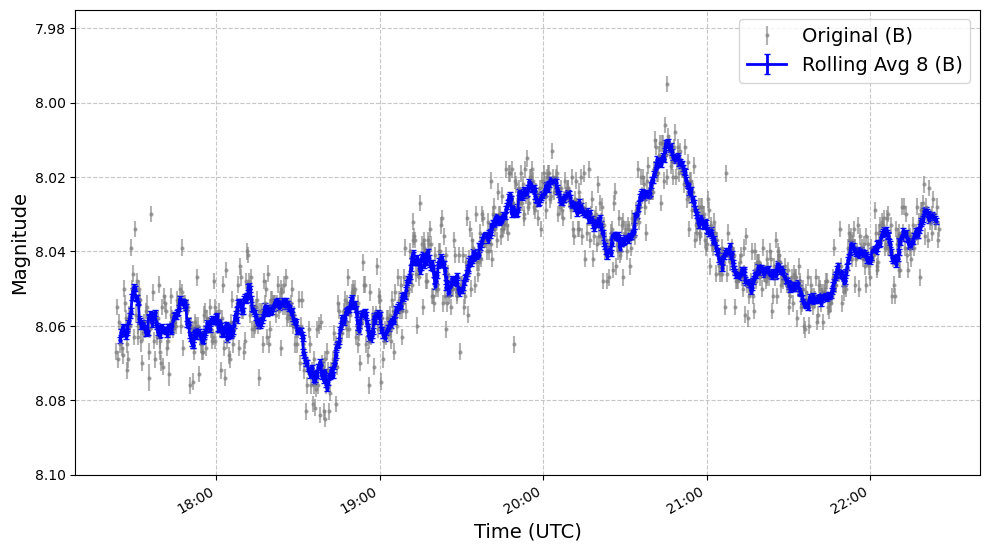

In [232]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
import matplotlib.dates as mdates
import scipy.signal as signal
import os

# Tukaj vpiši stevilo vseh zvezd katerim spremljamo fotometrijo
stevilo_vseh_zvezd = 2

# 1. Naložimo podatke
# Uporabimo regularni izraz '\s+' za ločevanje stolpcev (več presledkov)
stolpci = ['IMAGE', 'XCENTER', 'YCENTER', 'MAG', 'MERR', 'IFILTER', 'OTIME', 'ID']
pot_do_podatkov = 'rezultati_fotometrija_Mira.txt'

df = pd.read_csv(pot_do_podatkov, sep=r'\s+', names=stolpci)

# 2. Očistimo 'INDEF' vrednosti in pretvorimo v številke
# IRAF zapiše INDEF, kadar zvezde ne more izmeriti. To zamenjamo z NaN in odstranimo.
df['MAG'] = pd.to_numeric(df['MAG'], errors='coerce')
df['MERR'] = pd.to_numeric(df['MERR'], errors='coerce')
df['OTIME'] = pd.to_numeric(df['OTIME'], errors='coerce')
df['XCENTER'] = pd.to_numeric(df['XCENTER'], errors='coerce')
df['YCENTER'] = pd.to_numeric(df['YCENTER'], errors='coerce')

# Določitev pravega ID-ja pred kakršnimkoli brisanjem!
# Uporabimo matematični trik, o katerem sva prej govorila
df['PRAVI_ID'] = (df['ID'] - 1) % stevilo_vseh_zvezd + 1
# Sedaj lahko pobrišemo INDEF meritve
df = df.dropna(subset=['MAG', 'OTIME'])

# TUKAJ VPIŠI PRAVE ID-JE:
mira_id = 1          # ID Mire v big anulus podatkih je 2

ref_zvezda_id = 2



# 1. Izluščimo samo našo referenčno zvezdo in obdržimo LE nujne stolpce
ref_podatki = df[df['PRAVI_ID'] == ref_zvezda_id][['IMAGE', 'MAG', 'MERR']]

# 2. Preimenujemo no njena stolpca, da ju kasneje ločimo od Mire
ref_podatki = ref_podatki.rename(columns={'MAG': 'REF_MAG', 'MERR': 'REF_MERR'})

# 3. Združimo to referenčno "bazo" nazaj z glavno tabelo (povežemo preko pripadajoče slike)
df = pd.merge(df, ref_podatki, on='IMAGE')

# 4. Izračunamo razliko (diferencialno magnitudo) + dodamo tvojo konstanto 14.52
df['DIFF_MAG'] = df['MAG'] - df['REF_MAG'] + 9.7

# 5. Nova napaka je koren vsote kvadratov obeh posameznih napak
df['DIFF_MERR'] = np.sqrt(df['MERR']**2 + df['REF_MERR']**2)



# --------- ZDAJ LAHKO IZLUŠČIMO SAMO MIRO ---------
mira_df = df[df['PRAVI_ID'] == mira_id].copy()
# Pretvorba MJD v prave ure (datetime format)
casi = Time(mira_df['OTIME'].values, format='mjd')

# Lahko dodaš še 1 uro (ali 2 poleti) za slovenski lokalni čas, če želiš:
# from datetime import timedelta
# mira_df['URE'] = casi.datetime + timedelta(hours=1)

mira_df['URE'] = casi.datetime

# Sortiramo da bo krivulja pravilna
mira_df = mira_df.sort_values(by='URE')

# Tu odščipni morebitne divje podatke (recimo odreži prvih 5 in zadnjih 50 slik)
mira_df = mira_df[:-110]


# Naredimo drseče povprečje čez 5 sosednjih meritev. 
# "center=True" pomeni, da bo povprečje postavljeno na sredinsko točko (tretjo od petih)
velikost_okna = 8
mira_df['ROLLING_MAG'] = mira_df['DIFF_MAG'].rolling(window=velikost_okna, center=True).mean()

# Opcijsko: pri povprečenju N meritev se statistična napaka zmanjša za koren iz N!
mira_df['ROLLING_MERR'] = mira_df['DIFF_MERR'].rolling(window=velikost_okna, center=True).mean() / np.sqrt(velikost_okna)


# --- IZRIS ---
plt.figure(figsize=(10, 6))

for filter_ime, podatki_filtra in mira_df.groupby('IFILTER'):
    # Pri izrisu zdaj za Y podamo novo normirano magnitudo (DIFF_MAG)
#       plt.errorbar(podatki_filtra['OTIME'], podatki_filtra['DIFF_MAG'], 
#                    yerr=podatki_filtra['DIFF_MERR'], fmt='.', label=f'Filter {filter_ime}', 
#                    markersize=3, capsize=3)
    #Navaden plot
    #plt.scatter(podatki_filtra['URE'], podatki_filtra['DIFF_MAG'], label=f'Filter {filter_ime}')

    # 1. Bledo (alpha=0.2) prerišemo vse originalne surove meritve
    plt.errorbar(podatki_filtra['URE'], podatki_filtra['DIFF_MAG'], 
                 yerr=podatki_filtra['DIFF_MERR'], fmt='o', color='gray', alpha=0.6, 
                 markersize=2, label=f'Original ({filter_ime})')
                 
    # 2. Močno (brez alpha) pa izrišemo naše zglajeno drseče povprečje
    plt.errorbar(podatki_filtra['URE'], podatki_filtra['ROLLING_MAG'], 
                 yerr=podatki_filtra['ROLLING_MERR'], fmt='-o', color='blue', 
                 linewidth=2, markersize=2, capsize=2, label=f'Rolling Avg {velikost_okna} ({filter_ime})')


# Vrne os nazaj - da gre navzgor za bolj svetlo (čeprav se pri diferencialni lahko orientiraš tudi drugače)
#plt.gca().invert_yaxis() 

plt.xlabel('Time (UTC)', fontsize = '14')
plt.ylabel('Magnitude', fontsize = '14')
#plt.title(f'Light curve of Mira')
plt.legend(fontsize = '14')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.ylim(8.1, 7.975)
# TO DODAJ PRED plt.show():
# Povemo grafu, naj X os formatira samo kot yyyy-mm-dd HH:MM:SS
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gcf().autofmt_xdate() # Ta ukaz lepo nagne tekst ur pod kotom, da se ne prekrivajo!
plt.show()


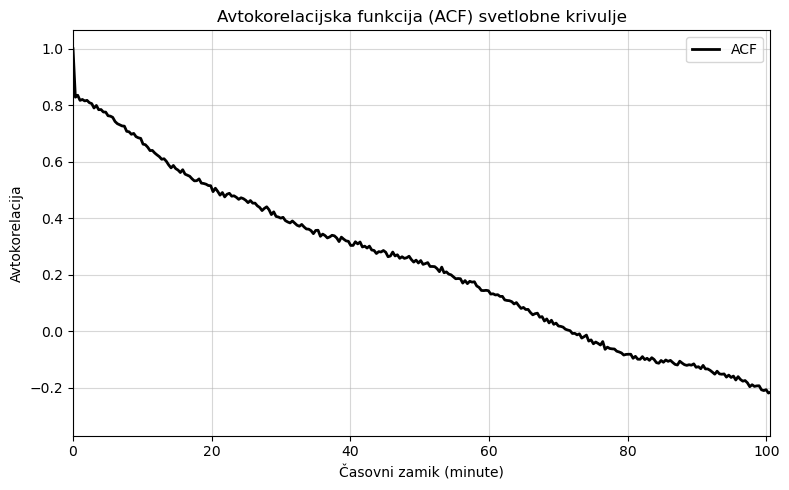

In [233]:
# 1. Priprava podatkov
# Vzamemo samo podatke, kjer rolling average ni NaN
valid_data = mira_df.dropna(subset=['DIFF_MAG']).copy()

# Čas pretvorimo v sekunde od začetka opazovanja
t_sec = (valid_data['URE'] - valid_data['URE'].iloc[0]).dt.total_seconds().values
mag = valid_data['DIFF_MAG'].values

# Za ACF moramo signal centrirati okoli 0 (odštejemo povprečje)
mag_anom = mag - np.mean(mag)

# 2. Izračun Avtokorelacijske funkcije (ACF)
# Uporabimo numpy.correlate. 'full' vrne korelacije za vse možne zamike
acf_full = np.correlate(mag_anom, mag_anom, mode='full')

# Zanimajo nas samo pozitivni zamiki (druga polovica niza)
acf = acf_full[len(acf_full)//2:]

# Normiramo ACF tako, da je maksimalna korelacija (pri zamiku 0) enaka 1
acf = acf / acf[0]
acf_mira = acf

# Določimo časovne zamike (lags) v sekundah in minutah
# Predpostavimo povprečen razmik med posnetki (ekspozicija + readout)
dt_mean = np.median(np.diff(t_sec))
lags_sec = np.arange(len(acf)) * dt_mean
lags_min = lags_sec / 60.0
lags_min_mira = lags_min

# 5. Izris ACF grafa
plt.figure(figsize=(8, 5))
plt.plot(lags_min, acf, 'k-', linewidth=2, label='ACF')
#plt.axhline(y=np.exp(-1), color='r', linestyle='--', label='1/e (~0.368)')
plt.xlabel('Časovni zamik (minute)')
plt.ylabel('Avtokorelacija')
plt.title('Avtokorelacijska funkcija (ACF) svetlobne krivulje')
plt.legend()
plt.grid(True, alpha=0.5)
plt.xlim(0, max(lags_min)/3) # Pokažemo samo prvo tretjino zamikov za lažje branje
plt.tight_layout()
plt.show()

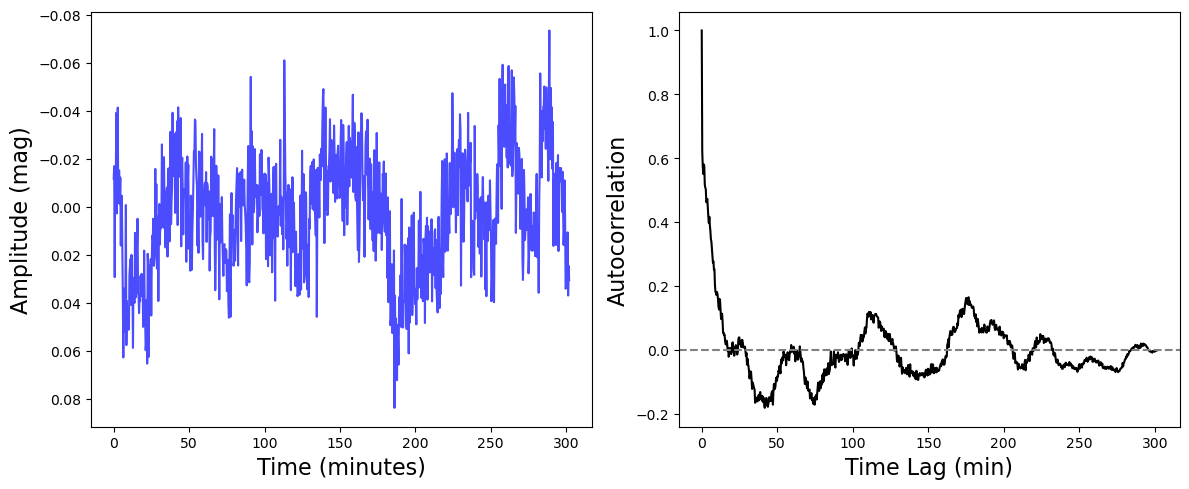

In [234]:
def simulate_drw_lightcurve(t_sec, tau, sigma_signal, sigma_noise):
    """
    Creates a synthetic light curve using a Damped Random Walk (Ornstein-Uhlenbeck) process
    and adds Gaussian white noise to it.
    """
    y = np.zeros(len(t_sec))
    
    # 1. Simulate the true physical signal (DRW)
    for i in range(1, len(t_sec)):
        dt = t_sec[i] - t_sec[i-1]
        decay = np.exp(-dt / tau)
        
        # Variance driving the random walk
        driving_var = (sigma_signal**2) * (1 - decay**2)
        
        # Next point is the damped previous step + a new random kick
        y[i] = y[i-1] * decay + np.random.normal(0, np.sqrt(driving_var))
        
    # 2. Add random instrumental noise (white noise)
    y_obs = y + np.random.normal(0, sigma_noise, len(t_sec))
    
    return y_obs

# --- TESTING WITH OUR DATA ---
# Take the time axis from our real observational data
t_sec_observed = (mira_df['URE'] - mira_df['URE'].iloc[0]).dt.total_seconds().values

# Choose parameters (you can play with these to match the shape of Mira)
tau_test = 30.0 * 60.0    # Characteristic time in seconds (e.g. 30 minutes)
sigma_sig_test = 0.03     # Amplitude of true physical flickering
sigma_noise_test = 0.015  # Amplitude of instrumental noise

# Create synthetic signal
y_synthetic = simulate_drw_lightcurve(t_sec_observed, tau_test, sigma_sig_test, sigma_noise_test)

# Calculate ACF of the synthetic signal
y_synthetic_anom = y_synthetic - np.mean(y_synthetic)
acf_synthetic_full = np.correlate(y_synthetic_anom, y_synthetic_anom, mode='full')
acf_synthetic = acf_synthetic_full[len(acf_synthetic_full)//2:]
acf_synthetic = acf_synthetic / acf_synthetic[0]

# --- PLOTTING ---
plt.figure(figsize=(12, 5))

# Plot 1: Synthetic Light Curve
plt.subplot(1, 2, 1)
plt.plot(t_sec_observed / 60.0, y_synthetic, 'b-', alpha=0.7)
#plt.title('Synthetic Light Curve (DRW + Noise)', fontsize=13)
plt.xlabel('Time (minutes)', fontsize=16)
plt.ylabel('Amplitude (mag)', fontsize=16)
plt.gca().invert_yaxis() # Invert y-axis for astronomical magnitudes

# Plot 2: ACF of Synthetic Signal
plt.subplot(1, 2, 2)
lags_min_synthetic = np.arange(len(acf_synthetic)) * np.median(np.diff(t_sec_observed)) / 60.0
plt.plot(lags_min_synthetic, acf_synthetic, 'k-', linewidth=1.5)
plt.axhline(0, color='gray', linestyle='--')
#plt.title('ACF of Synthetic Signal', fontsize=13)
plt.xlabel('Time Lag (min)', fontsize=16)
plt.ylabel('Autocorrelation', fontsize=16) # <--- Dodana Y os

plt.tight_layout()
plt.show()


--- REZULTATI FITANJA NA CELOTNI ACF ---
Delež pravega signala v meritvah: 100.5 %
Delež naključnega šuma v meritvah: -0.5 %
Karakteristični čas (tau): 25.7 minut


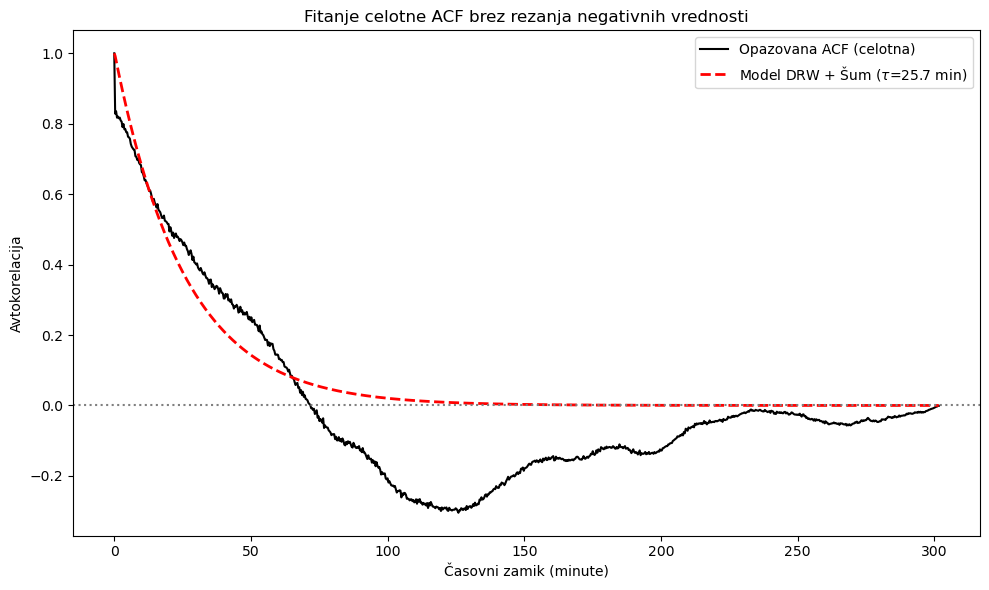

In [235]:
from scipy.optimize import curve_fit

# Nova funkcija za fitanje, ki VKlJUČUJE delta funkcijo za šum pri t=0
def drw_plus_noise_model(t, f_signal, tau):
    """
    f_signal: delež variance, ki je pravi fizikalni signal (med 0 in 1)
    1 - f_signal: delež, ki je naključni beli šum
    tau: naš iskani karakteristični čas
    """
    # Za t > 0 je model eksponentna funkcija, pomnožena z deležem signala
    rezultat = f_signal * np.exp(-t / tau)
    
    # Pri t=0 mora biti avtokorelacija točno 1.0 (ker vključuje 100% šuma in 100% signala)
    # Ker uporabljamo numpy arrays, t[0] je naš ničelni zamik.
    rezultat[0] = 1.0 
    
    return rezultat

# PODATKI: Vzamemo CELOTNO avtokorelacijo (NIČ VEČ REZANJA negativnih ali prve točke!)
t_fit_vse = lags_min
acf_fit_vse = acf

# Fitanje (začetni približek: 80% je signal, tau=30 minut)
popt_vse, _ = curve_fit(drw_plus_noise_model, t_fit_vse, acf_fit_vse, p0=[0.80, 30.0])

f_signal_opt, tau_opt = popt_vse
f_noise_opt = 1.0 - f_signal_opt

print("--- REZULTATI FITANJA NA CELOTNI ACF ---")
print(f"Delež pravega signala v meritvah: {f_signal_opt*100:.1f} %")
print(f"Delež naključnega šuma v meritvah: {f_noise_opt*100:.1f} %")
print(f"Karakteristični čas (tau): {tau_opt:.1f} minut")

# Izris
plt.figure(figsize=(10, 6))
plt.plot(t_fit_vse, acf_fit_vse, 'k-', linewidth=1.5, label='Opazovana ACF (celotna)')
plt.plot(t_fit_vse, drw_plus_noise_model(t_fit_vse, f_signal_opt, tau_opt), 'r--', 
         linewidth=2, label=f'Model DRW + Šum ($\\tau$={tau_opt:.1f} min)')

plt.axhline(0, color='gray', linestyle=':')
plt.xlabel('Časovni zamik (minute)')
plt.ylabel('Avtokorelacija')
plt.title('Fitanje celotne ACF brez rezanja negativnih vrednosti')
plt.legend()
plt.tight_layout()
plt.show()

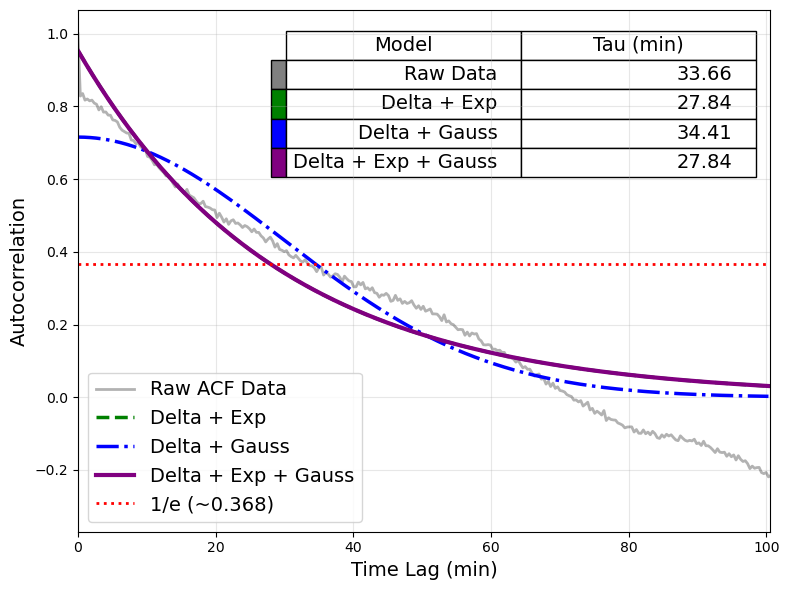

--- Final Model (Delta + Exp + Gauss) Results ---
Characteristic time (tau): 1670.7 s (27.84 min)
Estimated Accretion Disk Size:
R = 5.01e+11 m
R = 719.9320 R_Sun
R = 3.347972 AU



In [236]:
from scipy.optimize import curve_fit
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DEFINITIONS OF MODELS ---

def delta_func(t):
    if np.isscalar(t):
        return 1.0 if t == 0 else 0.0
    else:
        d = np.zeros_like(t, dtype=float)
        d[t == 0] = 1.0
        return d

# Model: Delta + Exponential
def model_exp(t, A, tau_exp, D):
    tau_exp = max(tau_exp, 1e-5)
    return A * np.exp(-t / tau_exp) + D * delta_func(t)

# Model: Delta + Gauss
def model_gauss(t, B, sigma, D):
    sigma = max(sigma, 1e-5)
    return B * np.exp(-(t**2) / (2 * sigma**2)) + D * delta_func(t)

# Model: Delta + Exponential + Gauss
def model_full(t, A, tau_exp, B, sigma, D):
    tau_exp = max(tau_exp, 1e-5)
    sigma = max(sigma, 1e-5)
    return A * np.exp(-t / tau_exp) + B * np.exp(-(t**2) / (2 * sigma**2)) + D * delta_func(t)

# Helper function to find model crossing at 1/e
def find_tau_model(model_func, popt, t_fit):
    def target_func(t):
        return model_func(t, *popt) - np.exp(-1)
    try:
        dt_start = max(1.0, t_fit[1]) if len(t_fit) > 1 else 1.0
        res = root_scalar(target_func, bracket=[dt_start, t_fit[-1]], method='brentq')
        return res.root
    except ValueError:
        return np.nan

# --- 2. DATA PREP & FITTING ---

max_lag_fit = max(lags_sec) / 3
mask_fit = lags_sec <= max_lag_fit

t_fit = lags_sec[mask_fit]
acf_fit = acf[mask_fit]

# 2.1. Raw Data tau (1/e) read directly from graph
pad_pod_1e = np.where(acf < np.exp(-1))[0]
if len(pad_pod_1e) > 0:
    tau_direct_sec = lags_sec[pad_pod_1e[0]]
    tau_direct_min = lags_min[pad_pod_1e[0]]
else:
    tau_direct_min = np.nan

# 2.2. Fit Delta + Exponential
p0_exp = [0.8, 200.0, 0.2]
bounds_exp = (0, [2.0, np.inf, 2.0])
popt_exp, _ = curve_fit(model_exp, t_fit, acf_fit, p0=p0_exp, bounds=bounds_exp, maxfev=5000)
tau_exp_sec = find_tau_model(model_exp, popt_exp, t_fit)
tau_exp_min = tau_exp_sec / 60.0 if not np.isnan(tau_exp_sec) else np.nan

# 2.3. Fit Delta + Gauss
p0_gauss = [0.8, 200.0, 0.2]
bounds_gauss = (0, [2.0, np.inf, 2.0])
popt_gauss, _ = curve_fit(model_gauss, t_fit, acf_fit, p0=p0_gauss, bounds=bounds_gauss, maxfev=5000)
tau_gauss_sec = find_tau_model(model_gauss, popt_gauss, t_fit)
tau_gauss_min = tau_gauss_sec / 60.0 if not np.isnan(tau_gauss_sec) else np.nan

# 2.4. Fit Delta + Exponential + Gauss
p0_full = [0.4, 200.0, 0.4, 100.0, 0.2]
bounds_full = (0, [2.0, np.inf, 2.0, np.inf, 2.0])
popt_full, _ = curve_fit(model_full, t_fit, acf_fit, p0=p0_full, bounds=bounds_full, maxfev=5000)
tau_full_sec = find_tau_model(model_full, popt_full, t_fit)
tau_full_min = tau_full_sec / 60.0 if not np.isnan(tau_full_sec) else np.nan

# --- 3. PLOTTING ---

fig, ax = plt.subplots(figsize=(8, 6))

# 3.1. Raw Data
ax.plot(lags_min, acf, color='black', linestyle='-', linewidth=2.0, alpha=0.3, label='Raw ACF Data')

# 3.2. Generate smooth plot lines (skipping t=0 to avoid the delta drop visually)
t_plot_sec = np.linspace(0, max(t_fit), 2000)
t_plot_sec_zvezno = t_plot_sec[1:]
t_plot_min = t_plot_sec_zvezno / 60.0

y_exp = model_exp(t_plot_sec_zvezno, *popt_exp)
y_gauss = model_gauss(t_plot_sec_zvezno, *popt_gauss)
y_full = model_full(t_plot_sec_zvezno, *popt_full)

# Plot fitted models
ax.plot(t_plot_min, y_exp, color='green', linestyle='--', linewidth=2.5, label='Delta + Exp')
ax.plot(t_plot_min, y_gauss, color='blue', linestyle='-.', linewidth=2.5, label='Delta + Gauss')
ax.plot(t_plot_min, y_full, color='purple', linestyle='-', linewidth=3.0, label='Delta + Exp + Gauss')

# 1/e horizontal line
ax.axhline(y=np.exp(-1), color='red', linestyle=':', linewidth=2.0, label='1/e (~0.368)')

ax.set_xlabel('Time Lag (min)', fontsize=14)
ax.set_ylabel('Autocorrelation', fontsize=14)
#ax.set_title('Mira', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(lags_min)/3)
ax.grid(True, alpha=0.3)

# Add standard legend
ax.legend(loc='lower left', fontsize=14)

# 3.3. Add a summary table for tau values directly on the plot
cell_text = [
    ['Raw Data', f"{tau_direct_min:.2f}" if not np.isnan(tau_direct_min) else "N/A"],
    ['Delta + Exp', f"{tau_exp_min:.2f}" if not np.isnan(tau_exp_min) else "N/A"],
    ['Delta + Gauss', f"{tau_gauss_min:.2f}" if not np.isnan(tau_gauss_min) else "N/A"],
    ['Delta + Exp + Gauss', f"{tau_full_min:.2f}" if not np.isnan(tau_full_min) else "N/A"]
]
row_colors = ['grey', 'green', 'blue', 'purple']

the_table = ax.table(cellText=cell_text,
                     colLabels=['Model', r'Tau (min)'],
                     rowColours=row_colors,
                     rowLabels=['  ', '  ', '  ', '  '], # Empty strings to act as color swatches
                     loc='upper right',
                     bbox=[0.3, 0.68, 0.68, 0.28]) # [x, y, width, height]

the_table.auto_set_font_size(False)
the_table.set_fontsize(14)

plt.tight_layout()
plt.show()

# --- 4. TEXT OUTPUT ---
if not np.isnan(tau_full_min):
    print("--- Final Model (Delta + Exp + Gauss) Results ---")
    c = 299792458 # speed of light in m/s
    R_model_m = c * tau_full_sec
    R_model_rsun = R_model_m / 6.957e8
    R_model_au = R_model_m / 1.496e11
    
    print(f"Characteristic time (tau): {tau_full_sec:.1f} s ({tau_full_min:.2f} min)")
    print(f"Estimated Accretion Disk Size:")
    print(f"R = {R_model_m:.2e} m")
    print(f"R = {R_model_rsun:.4f} R_Sun")
    print(f"R = {R_model_au:.6f} AU\n")


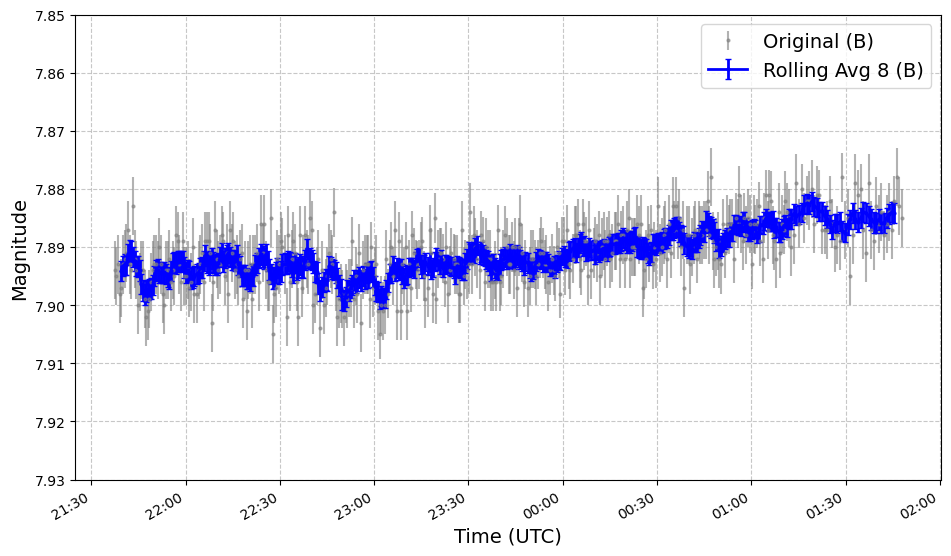

In [237]:
# Tukaj vpiši stevilo vseh zvezd katerim spremljamo fotometrijo
stevilo_vseh_zvezd = 2

# 1. Naložimo podatke
# Uporabimo regularni izraz '\s+' za ločevanje stolpcev (več presledkov)
stolpci = ['IMAGE', 'XCENTER', 'YCENTER', 'MAG', 'MERR', 'IFILTER', 'OTIME', 'ID']
pot_do_podatkov = 'rezultati_fotometrija_AG_Dra.txt'

df = pd.read_csv(pot_do_podatkov, sep=r'\s+', names=stolpci)

# 2. Očistimo 'INDEF' vrednosti in pretvorimo v številke
# IRAF zapiše INDEF, kadar zvezde ne more izmeriti. To zamenjamo z NaN in odstranimo.
df['MAG'] = pd.to_numeric(df['MAG'], errors='coerce')
df['MERR'] = pd.to_numeric(df['MERR'], errors='coerce')
df['OTIME'] = pd.to_numeric(df['OTIME'], errors='coerce')
df['XCENTER'] = pd.to_numeric(df['XCENTER'], errors='coerce')
df['YCENTER'] = pd.to_numeric(df['YCENTER'], errors='coerce')

# Določitev pravega ID-ja pred kakršnimkoli brisanjem!
# Uporabimo matematični trik, o katerem sva prej govorila
df['PRAVI_ID'] = (df['ID'] - 1) % stevilo_vseh_zvezd + 1
# Sedaj lahko pobrišemo INDEF meritve
df = df.dropna(subset=['MAG', 'OTIME'])

# TUKAJ VPIŠI PRAVE ID-JE:
mira_id = 1          # ID Mire v big anulus podatkih je 2

ref_zvezda_id = 2



# 1. Izluščimo samo našo referenčno zvezdo in obdržimo LE nujne stolpce
ref_podatki = df[df['PRAVI_ID'] == ref_zvezda_id][['IMAGE', 'MAG', 'MERR']]

# 2. Preimenujemo no njena stolpca, da ju kasneje ločimo od Mire
ref_podatki = ref_podatki.rename(columns={'MAG': 'REF_MAG', 'MERR': 'REF_MERR'})

# 3. Združimo to referenčno "bazo" nazaj z glavno tabelo (povežemo preko pripadajoče slike)
df = pd.merge(df, ref_podatki, on='IMAGE')

# 4. Izračunamo razliko (diferencialno magnitudo) + dodamo tvojo konstanto 14.52
df['DIFF_MAG'] = df['MAG'] - df['REF_MAG'] + 7.6

# 5. Nova napaka je koren vsote kvadratov obeh posameznih napak
df['DIFF_MERR'] = np.sqrt(df['MERR']**2 + df['REF_MERR']**2)



# --------- ZDAJ LAHKO IZLUŠČIMO SAMO MIRO ---------
mira_df = df[df['PRAVI_ID'] == mira_id].copy()
# Pretvorba MJD v prave ure (datetime format)
casi = Time(mira_df['OTIME'].values, format='mjd')

# Lahko dodaš še 1 uro (ali 2 poleti) za slovenski lokalni čas, če želiš:
# from datetime import timedelta
# mira_df['URE'] = casi.datetime + timedelta(hours=1)

mira_df['URE'] = casi.datetime

# Sortiramo da bo krivulja pravilna
mira_df = mira_df.sort_values(by='URE')

# Tu odščipni morebitne divje podatke (recimo odreži prvih 5 in zadnjih 50 slik)
mira_df = mira_df[:-50]


# Naredimo drseče povprečje čez 5 sosednjih meritev. 
# "center=True" pomeni, da bo povprečje postavljeno na sredinsko točko (tretjo od petih)
velikost_okna = 8
mira_df['ROLLING_MAG'] = mira_df['DIFF_MAG'].rolling(window=velikost_okna, center=True).mean()

# Opcijsko: pri povprečenju N meritev se statistična napaka zmanjša za koren iz N!
mira_df['ROLLING_MERR'] = mira_df['DIFF_MERR'].rolling(window=velikost_okna, center=True).mean() / np.sqrt(velikost_okna)


# --- IZRIS ---
plt.figure(figsize=(10, 6))

for filter_ime, podatki_filtra in mira_df.groupby('IFILTER'):
    # Pri izrisu zdaj za Y podamo novo normirano magnitudo (DIFF_MAG)
#       plt.errorbar(podatki_filtra['OTIME'], podatki_filtra['DIFF_MAG'], 
#                    yerr=podatki_filtra['DIFF_MERR'], fmt='.', label=f'Filter {filter_ime}', 
#                    markersize=3, capsize=3)
    #Navaden plot
    #plt.scatter(podatki_filtra['URE'], podatki_filtra['DIFF_MAG'], label=f'Filter {filter_ime}')

    # 1. Bledo (alpha=0.2) prerišemo vse originalne surove meritve
    plt.errorbar(podatki_filtra['URE'], podatki_filtra['DIFF_MAG'], 
                 yerr=podatki_filtra['DIFF_MERR'], fmt='o', color='gray', alpha=0.6, 
                 markersize=2, label=f'Original ({filter_ime})')
                 
    # 2. Močno (brez alpha) pa izrišemo naše zglajeno drseče povprečje
    plt.errorbar(podatki_filtra['URE'], podatki_filtra['ROLLING_MAG'], 
                 yerr=podatki_filtra['ROLLING_MERR'], fmt='-o', color='blue', 
                 linewidth=2, markersize=2, capsize=2, label=f'Rolling Avg {velikost_okna} ({filter_ime})')


# Vrne os nazaj - da gre navzgor za bolj svetlo (čeprav se pri diferencialni lahko orientiraš tudi drugače)
#plt.gca().invert_yaxis() 

plt.xlabel('Time (UTC)', fontsize=14)
plt.ylabel('Magnitude', fontsize=14)
#plt.title(f'Svetlobna krivulja zvezde)')
plt.legend(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.ylim(7.93, 7.85)
# TO DODAJ PRED plt.show():
# Povemo grafu, naj X os formatira samo kot yyyy-mm-dd HH:MM:SS
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gcf().autofmt_xdate() # Ta ukaz lepo nagne tekst ur pod kotom, da se ne prekrivajo!
plt.show()


In [238]:
# 1. Priprava podatkov
# Vzamemo samo podatke, kjer rolling average ni NaN
valid_data = mira_df.dropna(subset=['DIFF_MAG']).copy()

# Čas pretvorimo v sekunde od začetka opazovanja
t_sec = (valid_data['URE'] - valid_data['URE'].iloc[0]).dt.total_seconds().values
mag = valid_data['DIFF_MAG'].values

# Za ACF moramo signal centrirati okoli 0 (odštejemo povprečje)
mag_anom = mag - np.mean(mag)

# 2. Izračun Avtokorelacijske funkcije (ACF)
# Uporabimo numpy.correlate. 'full' vrne korelacije za vse možne zamike
acf_full = np.correlate(mag_anom, mag_anom, mode='full')

# Zanimajo nas samo pozitivni zamiki (druga polovica niza)
acf = acf_full[len(acf_full)//2:]

# Normiramo ACF tako, da je maksimalna korelacija (pri zamiku 0) enaka 1
acf = acf / acf[0]
acf_ag_dra = acf

# Določimo časovne zamike (lags) v sekundah in minutah
# Predpostavimo povprečen razmik med posnetki (ekspozicija + readout)
dt_mean = np.median(np.diff(t_sec))
lags_sec = np.arange(len(acf)) * dt_mean
lags_min = lags_sec / 60.0
lags_min_ag_dra = lags_min


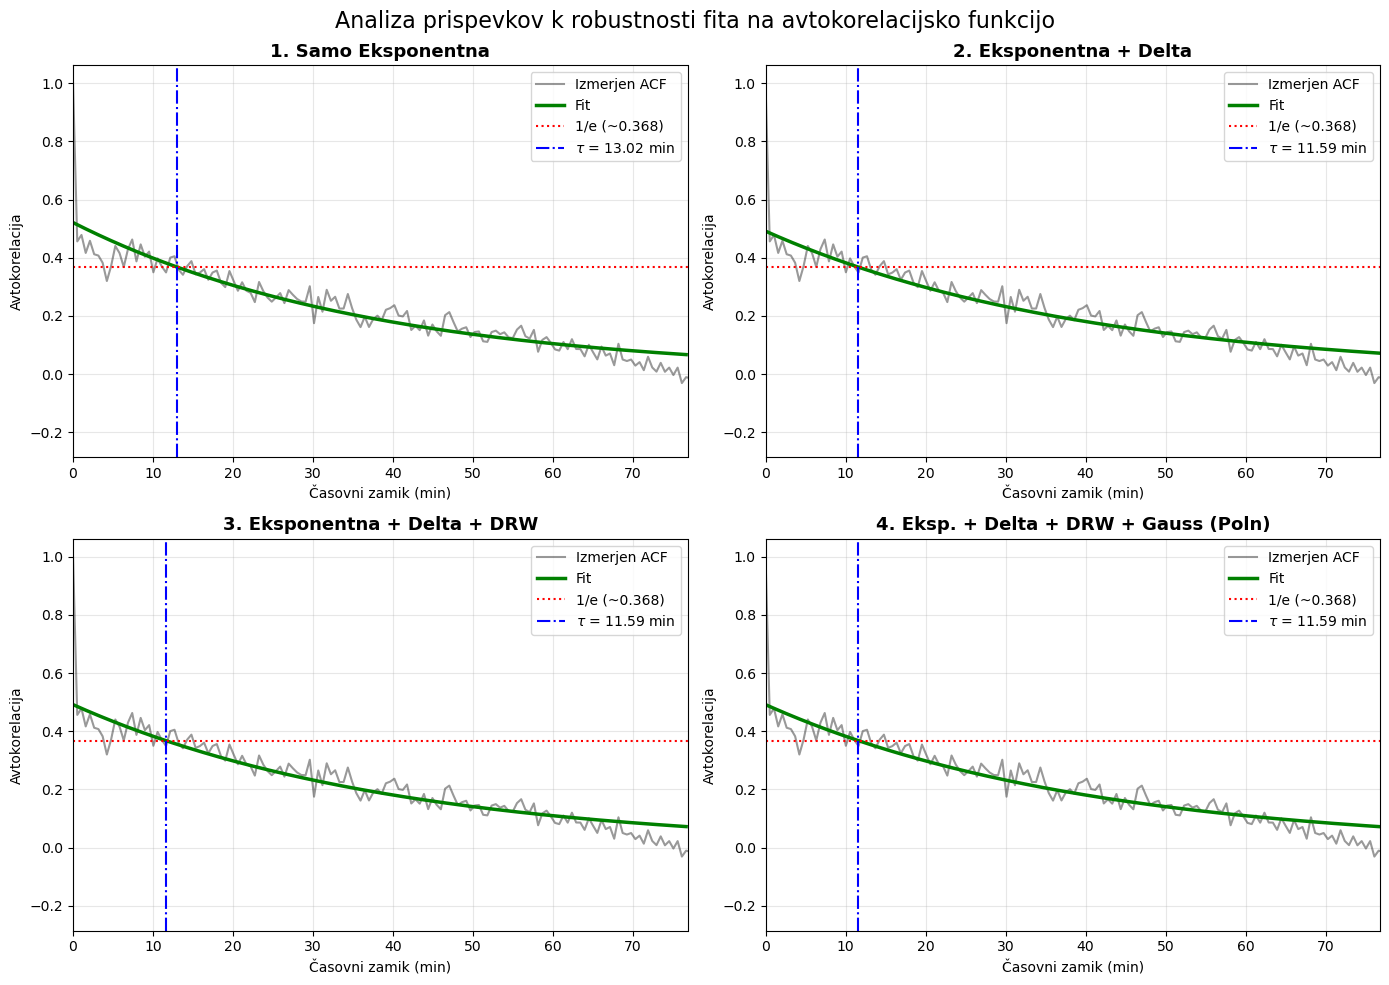

--- Numerični rezultati POLNEGA MODELA (Model 4) ---
Karakteristični čas tau (z vsemi prispevki): 695.7 s (11.59 min)
Ocenjena velikost akrecijskega diska (R = c * tau): 299.7921 R_Sonce


In [239]:
# --- 1. DEFINICIJA KOMPONENT IN MODELOV ---

def delta_func(t):
    """Pomožna funkcija za Kroneckerjevo delto pri lag=0."""
    if np.isscalar(t):
        return 1.0 if t == 0 else 0.0
    else:
        d = np.zeros_like(t, dtype=float)
        d[t == 0] = 1.0
        return d

# Model 1: Samo eksponentna funkcija
def model_1(t, A, tau_exp):
    tau_exp = max(tau_exp, 1e-5)
    return A * np.exp(-t / tau_exp)

# Model 2: Eksponentna + Delta funkcija
def model_2(t, A, tau_exp, D):
    tau_exp = max(tau_exp, 1e-5)
    return A * np.exp(-t / tau_exp) + D * delta_func(t)

# Model 3: Eksponentna + DRW (katera je 2. eksponent) + Delta funkcija
def model_3(t, A, tau_exp, C, tau_drw, D):
    tau_exp = max(tau_exp, 1e-5)
    tau_drw = max(tau_drw, 1e-5)
    return A * np.exp(-t / tau_exp) + C * np.exp(-t / tau_drw) + D * delta_func(t)

# Model 4: Poln sistem dveh eksponentnih, gaussove in delta (naš prej preizkušen)
def model_4(t, A, tau_exp, B, sigma, C, tau_drw, D):
    tau_exp = max(tau_exp, 1e-5)
    sigma = max(sigma, 1e-5)
    tau_drw = max(tau_drw, 1e-5)
    return (A * np.exp(-t / tau_exp) + 
            B * np.exp(-(t**2) / (2 * sigma**2)) + 
            C * np.exp(-t / tau_drw) + 
            D * delta_func(t))

# Pomožna funkcija za iskanje tau = 1/e v zglajenem fitu
def find_tau_model(model_func, popt, t_fit):
    def target_func(t):
        return model_func(t, *popt) - np.exp(-1)
    try:
        dt_start = max(1.0, t_fit[1]) if len(t_fit) > 1 else 1.0
        res = root_scalar(target_func, bracket=[dt_start, t_fit[-1]], method='brentq')
        return res.root
    except ValueError:
        return np.nan


# --- 2. PRIPRAVA PODATKOV IN OPTIMIZACIJA (FITANJE) ---

# Še vedno smatramo, da nas zanima le začetni, najbolj zanesljiv del ACF
max_lag_fit = max(lags_sec) / 3
mask_fit = lags_sec <= max_lag_fit

t_fit = lags_sec[mask_fit]
acf_fit = acf[mask_fit]

# Fit Model 1
p0_1 = [1.0, 200.0]
bounds_1 = (0, [2.0, np.inf])
popt_1, _ = curve_fit(model_1, t_fit, acf_fit, p0=p0_1, bounds=bounds_1, maxfev=5000)
tau_1 = find_tau_model(model_1, popt_1, t_fit)

# Fit Model 2
p0_2 = [0.8, 200.0, 0.2]
bounds_2 = (0, [2.0, np.inf, 2.0])
popt_2, _ = curve_fit(model_2, t_fit, acf_fit, p0=p0_2, bounds=bounds_2, maxfev=5000)
tau_2 = find_tau_model(model_2, popt_2, t_fit)

# Fit Model 3
p0_3 = [0.4, 100.0, 0.4, 500.0, 0.2]
bounds_3 = (0, [2.0, np.inf, 2.0, np.inf, 2.0])
popt_3, _ = curve_fit(model_3, t_fit, acf_fit, p0=p0_3, bounds=bounds_3, maxfev=5000)
tau_3 = find_tau_model(model_3, popt_3, t_fit)

# Fit Model 4
p0_4 = [0.25, 200.0, 0.25, 100.0, 0.25, 500.0, 0.25]
bounds_4 = (0, [2.0, np.inf, 2.0, np.inf, 2.0, np.inf, 2.0])
popt_4, _ = curve_fit(model_4, t_fit, acf_fit, p0=p0_4, bounds=bounds_4, maxfev=5000)
tau_4 = find_tau_model(model_4, popt_4, t_fit)


# --- 3. SKUPNI IZRIS IN PRIMERJAVA ---

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

models = [model_1, model_2, model_3, model_4]
popts = [popt_1, popt_2, popt_3, popt_4]
taus = [tau_1, tau_2, tau_3, tau_4]
titles = [
    "1. Samo Eksponentna", 
    "2. Eksponentna + Delta", 
    "3. Eksponentna + Delta + DRW", 
    "4. Eksp. + Delta + DRW + Gauss (Poln)"
]

t_plot_sec = np.linspace(0, max(t_fit), 2000)
# Preskočimo t=0 zaradi delta funkcije na predogledih
t_plot_sec_zvezno = t_plot_sec [1:] #Lahko prvo točko odtranimo

for i in range(4):
    ax = axs[i]
    # Surov signal (lepa siva/črna)
    ax.plot(lags_min, acf, 'k-', linewidth=1.5, alpha=0.4, label='Izmerjen ACF')
    
    # Modelna funkcija
    y_pred = models[i](t_plot_sec_zvezno, *popts[i])
    ax.plot(t_plot_sec_zvezno / 60.0, y_pred, 'g-', linewidth=2.5, label='Fit')
    
    # Nivo 1/e
    ax.axhline(y=np.exp(-1), color='r', linestyle=':', label='1/e (~0.368)')
    
    # Karakterističen čas tau
    if not np.isnan(taus[i]):
        tau_min = taus[i] / 60.0
        ax.axvline(x=tau_min, color='b', linestyle='-.', label=f'$\\tau$ = {tau_min:.2f} min')
        
    ax.set_title(titles[i], fontsize=13, fontweight='bold')
    ax.set_xlabel('Časovni zamik (min)')
    ax.set_ylabel('Avtokorelacija')
    ax.set_xlim(0, max(lags_min)/3)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='upper right')

plt.suptitle('Analiza prispevkov k robustnosti fita na avtokorelacijsko funkcijo', fontsize=16)
plt.tight_layout()
plt.show()

# Na koncu izpištimo še samo numerični rezultat tistega najbolj izpoplčenega (št. 4):
print("--- Numerični rezultati POLNEGA MODELA (Model 4) ---")
if not np.isnan(tau_4):
    c = 299792458
    R_model_m = c * tau_4
    print(f"Karakteristični čas tau (z vsemi prispevki): {tau_4:.1f} s ({tau_4/60.0:.2f} min)")
    print(f"Ocenjena velikost akrecijskega diska (R = c * tau): {R_model_m/6.957e8:.4f} R_Sonce")
else:
    print("Pri polnem modelu tau nismo našli (funkcija ne seka 1/e v danem oknu).")


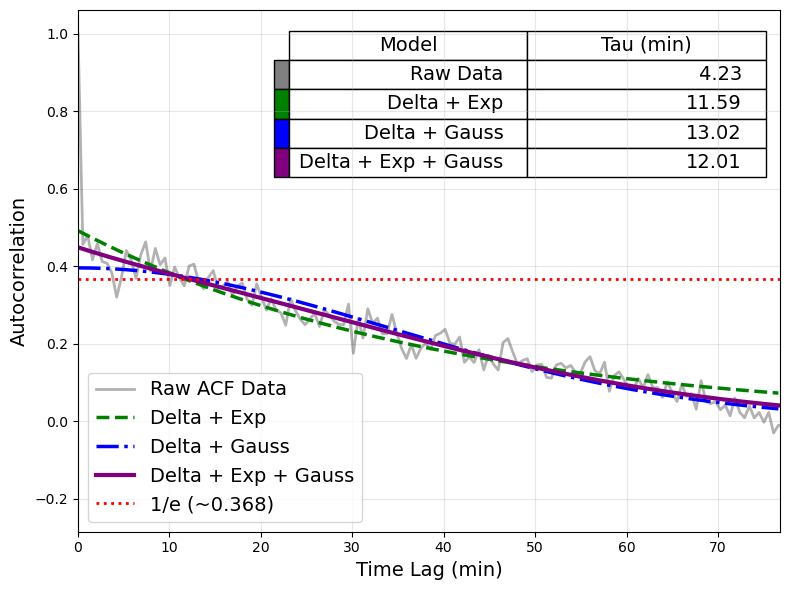

--- Final Model (Delta + Exp + Gauss) Results ---
Characteristic time (tau): 720.3 s (12.01 min)
Estimated Accretion Disk Size:
R = 2.16e+11 m
R = 310.4035 R_Sun
R = 1.443501 AU



In [240]:
from scipy.optimize import curve_fit
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DEFINITIONS OF MODELS ---

def delta_func(t):
    if np.isscalar(t):
        return 1.0 if t == 0 else 0.0
    else:
        d = np.zeros_like(t, dtype=float)
        d[t == 0] = 1.0
        return d

def model_exp(t, A, tau_exp, D):
    tau_exp = max(tau_exp, 1e-5)
    return A * np.exp(-t / tau_exp) + D * delta_func(t)

def model_gauss(t, B, sigma, D):
    sigma = max(sigma, 1e-5)
    return B * np.exp(-(t**2) / (2 * sigma**2)) + D * delta_func(t)

def model_full(t, A, tau_exp, B, sigma, D):
    tau_exp = max(tau_exp, 1e-5)
    sigma = max(sigma, 1e-5)
    return A * np.exp(-t / tau_exp) + B * np.exp(-(t**2) / (2 * sigma**2)) + D * delta_func(t)

def find_tau_model(model_func, popt, t_fit):
    def target_func(t):
        return model_func(t, *popt) - np.exp(-1)
    try:
        dt_start = max(1.0, t_fit[1]) if len(t_fit) > 1 else 1.0
        res = root_scalar(target_func, bracket=[dt_start, t_fit[-1]], method='brentq')
        return res.root
    except ValueError:
        return np.nan

# --- 2. DATA PREP & FITTING (Minutes) ---

max_lag_fit = max(lags_sec) / 3
mask_fit = lags_sec <= max_lag_fit

t_fit = lags_sec[mask_fit]
acf_fit = acf[mask_fit]

# 2.1. Raw Data tau (1/e)
pad_pod_1e = np.where(acf < np.exp(-1))[0]
if len(pad_pod_1e) > 0:
    tau_direct_sec = lags_sec[pad_pod_1e[0]]
    tau_direct_min = lags_min[pad_pod_1e[0]]
else:
    tau_direct_sec = np.nan
    tau_direct_min = np.nan

# Dinamičen začetni približek (reši problem dolgih skal AG Dra)
tau_guess = tau_direct_sec if not np.isnan(tau_direct_sec) else (max(lags_sec) / 10.0)

# 2.2. Fit Delta + Exponential
p0_exp = [0.8, tau_guess, 0.2]
bounds_exp = (0, [2.0, np.inf, 2.0])
popt_exp, _ = curve_fit(model_exp, t_fit, acf_fit, p0=p0_exp, bounds=bounds_exp, maxfev=10000)
tau_exp_sec = find_tau_model(model_exp, popt_exp, t_fit)
tau_exp_min = tau_exp_sec / 60.0 if not np.isnan(tau_exp_sec) else np.nan

# 2.3. Fit Delta + Gauss
p0_gauss = [0.8, tau_guess, 0.2]
bounds_gauss = (0, [2.0, np.inf, 2.0])
popt_gauss, _ = curve_fit(model_gauss, t_fit, acf_fit, p0=p0_gauss, bounds=bounds_gauss, maxfev=10000)
tau_gauss_sec = find_tau_model(model_gauss, popt_gauss, t_fit)
tau_gauss_min = tau_gauss_sec / 60.0 if not np.isnan(tau_gauss_sec) else np.nan

# 2.4. Fit Delta + Exponential + Gauss
p0_full = [0.4, tau_guess, 0.4, tau_guess/2.0, 0.2]
bounds_full = (0, [2.0, np.inf, 2.0, np.inf, 2.0])
popt_full, _ = curve_fit(model_full, t_fit, acf_fit, p0=p0_full, bounds=bounds_full, maxfev=10000)
tau_full_sec = find_tau_model(model_full, popt_full, t_fit)
tau_full_min = tau_full_sec / 60.0 if not np.isnan(tau_full_sec) else np.nan


# --- 3. PLOTTING ---

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(lags_min, acf, color='black', linestyle='-', linewidth=2.0, alpha=0.3, label='Raw ACF Data')

# Generate smooth plot lines in minutes
t_plot_sec = np.linspace(0, max(t_fit), 2000)
t_plot_sec_zvezno = t_plot_sec[1:]
t_plot_min = t_plot_sec_zvezno / 60.0

y_exp = model_exp(t_plot_sec_zvezno, *popt_exp)
y_gauss = model_gauss(t_plot_sec_zvezno, *popt_gauss)
y_full = model_full(t_plot_sec_zvezno, *popt_full)

ax.plot(t_plot_min, y_exp, color='green', linestyle='--', linewidth=2.5, label='Delta + Exp')
ax.plot(t_plot_min, y_gauss, color='blue', linestyle='-.', linewidth=2.5, label='Delta + Gauss')
ax.plot(t_plot_min, y_full, color='purple', linestyle='-', linewidth=3.0, label='Delta + Exp + Gauss')

ax.axhline(y=np.exp(-1), color='red', linestyle=':', linewidth=2.0, label='1/e (~0.368)')

ax.set_xlabel('Time Lag (min)', fontsize=14)
ax.set_ylabel('Autocorrelation', fontsize=14)
#ax.set_title('AG Dra', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(lags_min)/3)
ax.grid(True, alpha=0.3)

ax.legend(loc='lower left', fontsize=14)

# 3.3. Add a summary table for tau values directly on the plot
cell_text = [
    ['Raw Data', f"{tau_direct_min:.2f}" if not np.isnan(tau_direct_min) else "N/A"],
    ['Delta + Exp', f"{tau_exp_min:.2f}" if not np.isnan(tau_exp_min) else "N/A"],
    ['Delta + Gauss', f"{tau_gauss_min:.2f}" if not np.isnan(tau_gauss_min) else "N/A"],
    ['Delta + Exp + Gauss', f"{tau_full_min:.2f}" if not np.isnan(tau_full_min) else "N/A"]
]
row_colors = ['grey', 'green', 'blue', 'purple']

the_table = ax.table(cellText=cell_text,
                     colLabels=['Model', r'Tau (min)'],
                     rowColours=row_colors,
                     rowLabels=['  ', '  ', '  ', '  '], # Empty strings to act as color swatches
                     loc='upper right',
                     bbox=[0.3, 0.68, 0.68, 0.28]) # [x, y, width, height]

the_table.auto_set_font_size(False)
the_table.set_fontsize(14)

plt.tight_layout()
plt.show()

# --- 4. TEXT OUTPUT ---
if not np.isnan(tau_full_min):
    print("--- Final Model (Delta + Exp + Gauss) Results ---")
    c = 299792458
    R_model_m = c * tau_full_sec
    R_model_rsun = R_model_m / 6.957e8
    R_model_au = R_model_m / 1.496e11
    
    print(f"Characteristic time (tau): {tau_full_sec:.1f} s ({tau_full_min:.2f} min)")
    print(f"Estimated Accretion Disk Size:")
    print(f"R = {R_model_m:.2e} m")
    print(f"R = {R_model_rsun:.4f} R_Sun")
    print(f"R = {R_model_au:.6f} AU\n")
else:
    print("Pri polnem modelu tau nismo našli (funkcija ne seka 1/e v danem oknu).")


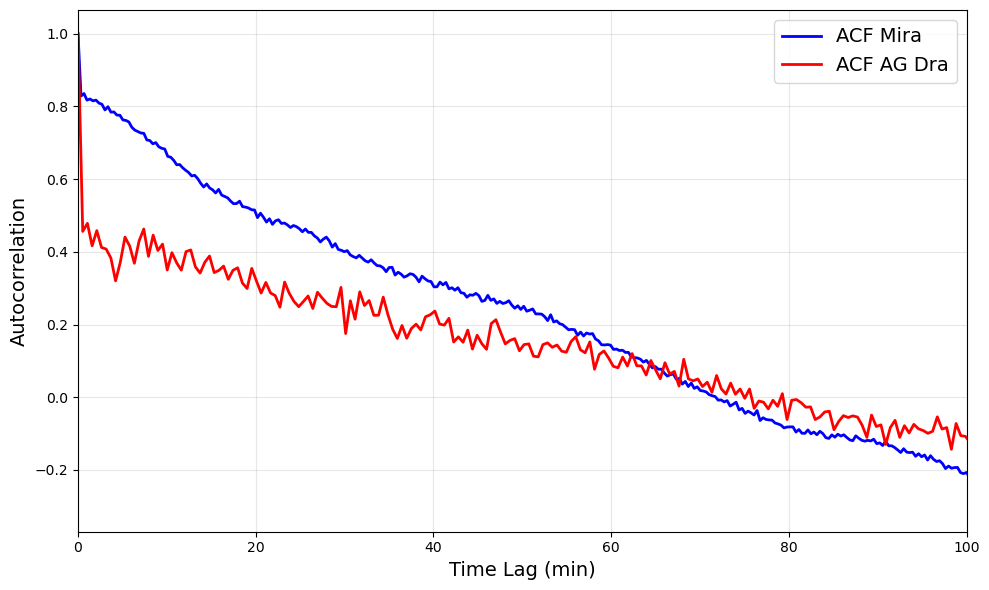

In [241]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

# Narišemo oba ACF-ja na isto x-os
ax.plot(lags_min_mira, acf_mira, color='blue', linestyle='-', linewidth=2.0, label='ACF Mira')
ax.plot(lags_min_ag_dra, acf_ag_dra, color='red', linestyle='-', linewidth=2.0, label='ACF AG Dra')

# Nastavimo skupno mejo x-osi na 100 minut
ax.set_xlim(0, 100)

# Enotne oznake osi
ax.set_xlabel('Time Lag (min)', fontsize=14)
ax.set_ylabel('Autocorrelation', fontsize=14)
#ax.set_title('Primerjava oblike ACF (Prvih 100 minut)', fontsize=14, fontweight='bold', pad=15)

ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=14)

plt.tight_layout()
plt.show()


Računam 20 simulacij z N=900 točkami...
Generiranje končano. Slika je shranjena kot 'figs/20_razlicnih_ACF.png'.


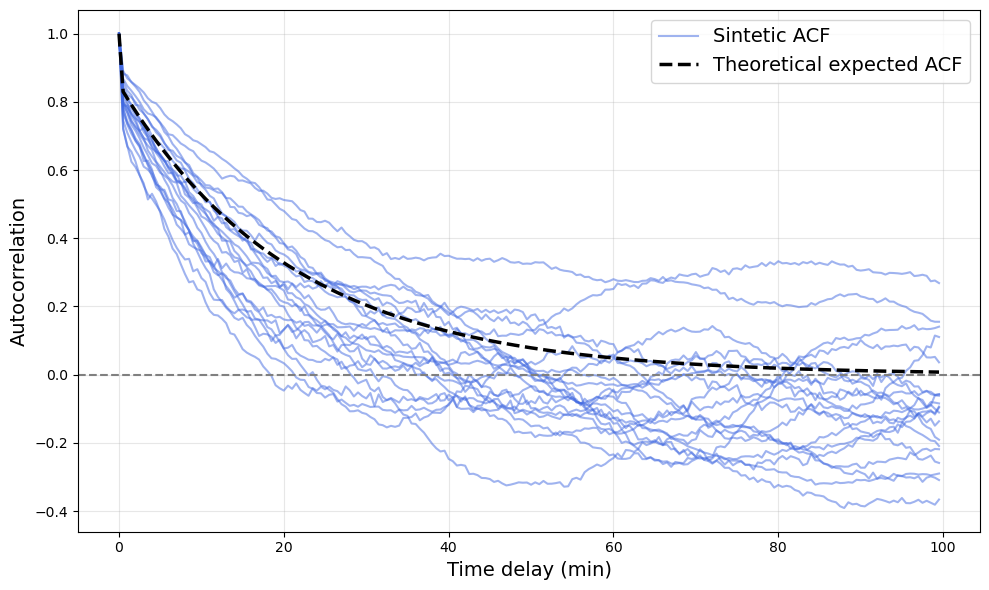

In [242]:
def simuliraj_in_izracunaj_acf_kratka(tau_min, f_sig, dt_min, max_lag_idx, N):
    """
    Ustvari sintetični signal dolžine N z DRW modelom in izračuna njegovo ACF.
    """
    y = np.zeros(N)
    
    tau_sec = tau_min * 60.0
    dt_sec = dt_min * 60.0
    
    decay = np.exp(-dt_sec / tau_sec)
    
    # Nastavimo skupno varianco na 1.0 (sigma_sig^2 = f_sig)
    sigma_sig = np.sqrt(f_sig)
    driving_std = np.sqrt((sigma_sig**2) * (1 - decay**2))
    
    # Hitra generacija zanke
    noise = np.random.normal(0, driving_std, N)
    for i in range(1, N):
        y[i] = y[i-1] * decay + noise[i]
        
    # Dodamo instrumentalni šum (sigma_noise^2 = 1 - f_sig)
    sigma_noise = np.sqrt(1.0 - f_sig)
    y_obs = y + np.random.normal(0, sigma_noise, N)
    
    # Izračunamo ACF
    y_anom = y_obs - np.mean(y_obs)
    acf_full = np.correlate(y_anom, y_anom, mode='full')
    acf_half = acf_full[N-1:]
    
    # Normiramo
    acf_norm = acf_half / acf_half[0]
    
    return acf_norm[:max_lag_idx]

# --- PARAMETRI ---
tau_min = 21.0       # Karakteristični čas (npr. podobno kot za Miro)
f_sig = 0.85         # Delež pravega signala (15% šuma)
dt_min = 0.5         # Razmik med meritvami v minutah
N = 900              # Število opazovanj (npr. dolžina enega opazovanja)
max_lag_idx = 200    # Do katerega zamika računamo (npr. 100 minut pri dt=0.5)
stevilo_simulacij = 20

lags_min = np.arange(max_lag_idx) * dt_min

plt.figure(figsize=(10, 6))

print(f"Računam {stevilo_simulacij} simulacij z N={N} točkami...")

# Izrišemo 20 različnih simulacij
for i in range(stevilo_simulacij):
    acf_synth = simuliraj_in_izracunaj_acf_kratka(tau_min, f_sig, dt_min, max_lag_idx, N)
    # Prvo simulacijo poimenujemo za legendo, ostale ne
    label = 'Sintetic ACF' if i == 0 else None
    plt.plot(lags_min, acf_synth, alpha=0.5, linewidth=1.5, color='royalblue', label=label)

# Dodamo še teoretično pričakovano krivuljo (za neskončno točk)
# ACF DRW modela eksponentno pada. Ker imamo šum, je delež signala f_sig na lag>0.
acf_teoreticna = np.exp(-(lags_min * 60.0) / (tau_min * 60.0)) * f_sig
acf_teoreticna[0] = 1.0 # Pri zamiku 0 je korelacija vedno 1

plt.plot(lags_min, acf_teoreticna, 'k--', linewidth=2.5, label='Theoretical expected ACF')
# Oblikovanje grafa
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Time delay (min)', fontsize=14)
plt.ylabel('Autocorrelation', fontsize=14)
#plt.title(f'{stevilo_simulacij} different ACF realizations from identical initial conditions\n' f'($\\tau$={tau_min} min, signal={f_sig*100}%, N={N} points)', fontsize=14)
plt.legend(fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Ustvarimo mapo 'figs', če morda ne obstaja
if not os.path.exists('figs'):
    os.makedirs('figs')

shrani_pot = 'figs/20_razlicnih_ACF.png'
plt.savefig(shrani_pot, dpi=150)
print(f"Generiranje končano. Slika je shranjena kot '{shrani_pot}'.")
# plt.show() # Odkomentiraj, če želiš, da se graf odpre v interaktivnem oknu (če ne uporabljaš samo shrani)
